In [1]:
# Notebook used to display the results from raytrace_3d.py

In [2]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import particle_tracker as pt
import ray_transfer_matrix as rtm

{'num_photons': '1000000', 'beam_size': '0.012', 'divergence': '0', 'flash_file': '/home/timoney/scratch/timoney/MagShockZ/simuls/3d_noshield/MagShockZ_hdf5_plt_cnt_0039', 'scaling_factor': '1.0', 'num_processors': '36', 'timestamp': '1772300764.95473'}


yt : [INFO     ] 2026-04-06 11:00:36,379 Parameters: current_time              = 1.0070266421119528e-08
yt : [INFO     ] 2026-04-06 11:00:36,380 Parameters: domain_dimensions         = [60 60 60]
yt : [INFO     ] 2026-04-06 11:00:36,382 Parameters: domain_left_edge          = [-0.85 -0.1  -0.85]
yt : [INFO     ] 2026-04-06 11:00:36,383 Parameters: domain_right_edge         = [0.85 1.6  0.85]
yt : [INFO     ] 2026-04-06 11:00:36,384 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-04-06 11:00:48,892 xlim = -0.850000 0.850000
yt : [INFO     ] 2026-04-06 11:00:48,894 ylim = -0.100000 1.600000
yt : [INFO     ] 2026-04-06 11:00:48,897 xlim = -0.850000 0.850000
yt : [INFO     ] 2026-04-06 11:00:48,898 ylim = -0.100000 1.600000
yt : [INFO     ] 2026-04-06 11:00:48,902 Making a fixed resolution buffer of (('flash', 'edens')) 800 by 800



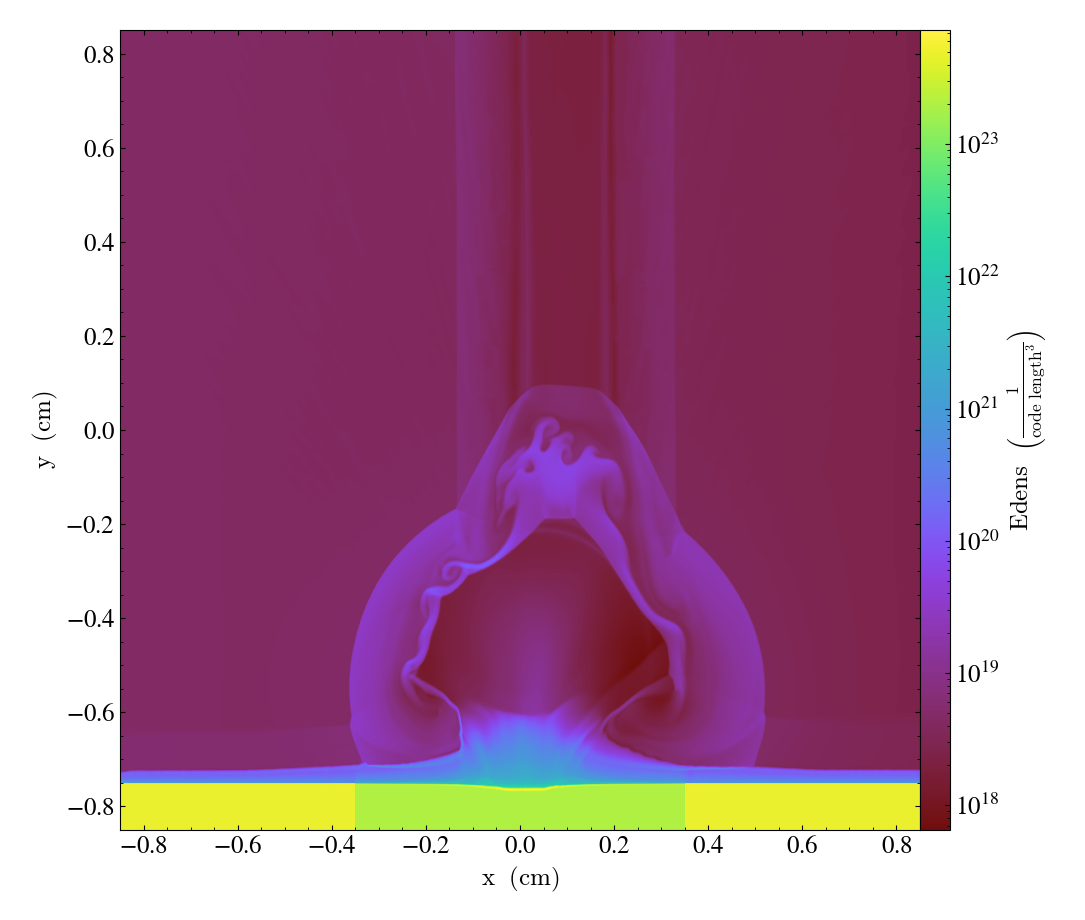

In [3]:
# Get data
import yt.units

ray_trace_dir = '../../traces/3d_noshield/raytrace_0039'
# ray_trace_dir = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_aperture/raytrace_0039_v1'
output_dir = '/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_noshield'

metadata = {}
raytrace_metadata = ray_trace_dir + '/metadata.txt'
with open(raytrace_metadata, 'r') as f:
    metadata_lines = f.readlines()
    for line in metadata_lines:
        key, value = line.strip().split(': ')
        metadata[key] = value

print(metadata)

ds = yt.load(metadata["flash_file"])

def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density
ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell") # same here

sl = yt.SlicePlot(ds, 'z', ('flash','edens'))
sl.show()

In [4]:
# print("Domain left edge:", ds.domain_left_edge)
# print("Domain right edge:", ds.domain_right_edge)
# print("Domain width:", ds.domain_width)

In [5]:
rf = np.load(f"{ray_trace_dir}/ray_output.npy")
beam_size = float(metadata["beam_size"])
photons = int(metadata["num_photons"])

det_size = 2*float(metadata['beam_size'])*10**3 # 10^3 to convert into mm
lens_rad=25
length=400
fp=0

sh = rtm.Shadowgraphy(r0=rf, focal_plane=fp, L=length, R=lens_rad, Lx=det_size, Ly=det_size)
sh.solve()
#lionz = rtm.LIONZ_approx()

lsc = rtm.Schlieren_LF(r0=rf, focal_plane=fp, L=length, R=lens_rad, Lx=det_size, Ly=det_size)
lsc.solve()
lsc.histogram(bin_scale=1)
sh.histogram(bin_scale=1)
# try plotting histogram

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2574, 3448))

In [12]:
# ds.r[('flash','z')]

focal plane [mm]: -0.02656250121071957


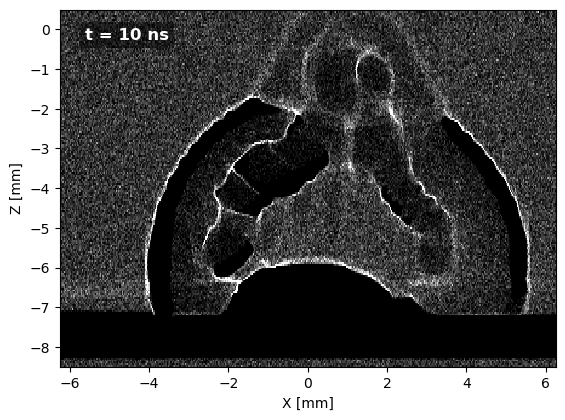

In [13]:
# define LIONZ optical system
focal_plane = (ds.r[('flash','z')][-1]+ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
focal_plane = focal_plane.v #take out yt unit
# focal_plane = -20 # manually set focal plane

print("focal plane [mm]:", focal_plane)


offset_mm = 0 # offset for focusing
Lens_FL = 400
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1
Lens_Rad = .5*75/2 # radius of lens
# Lx (int, optional): Detector size in x. Defaults to 18.
# Ly (float, optional): Detector size in y. Defaults to 13.5.
sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad) # must center grid
# sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad) # must center grid
sh.solve(d1=d1,d2=d2)
sh.histogram(bin_scale = 7)
# plot
fig, axs = plt.subplots()
cm='gray'
#clim=[0,15]

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H,90)

clim=(0,vmax*3) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

# add in time step
time_ns = ds.current_time.in_units('ns').v
axs.text(0.05, 0.95, f't = {time_ns:.0f} ns', 
         transform=axs.transAxes, 
         color='white', 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top',
         bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')) # Adds a readable background box

#offset_mm = 0
#sh_focused = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = 0, L=Lens_FL, R=Lens_Rad)
#sh_focused.solve(d1=d1,d2=d2)
#sh_focused.histogram(bin_scale = 7)
plt.ylabel('Z [mm]')
plt.xlabel('X [mm]')
plt.ylim(-8.5, 0.5)
plt.xlim(-6.25, 6.25)
plt.savefig(f'{output_dir}/sh_3d_t={time_ns:.0f}.png', bbox_inches='tight')
# plt.savefig(f'{output_dir}/sh_3d_t={time_ns:.0f}_fp={np.round(focal_plane+offset_mm,2)}.png', bbox_inches='tight')
# plt.savefig(f'{output_dir}/sh_t_{time_ns:.0f}ns_fp_{np.round(focal_plane+offset_mm,2)}.png', bbox_inches='tight')

3465.7


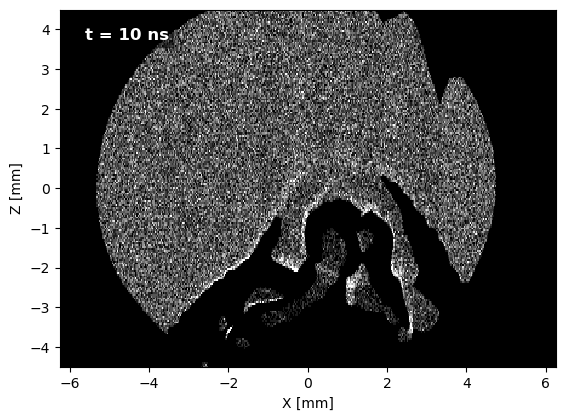

In [38]:
focal_plane = 0
offset_mm = 0 # offset for focusing
Lens_FL = 500
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1
print(d2)
Lens_Rad = .5*75/2 # radius of lens

ap_dist = 300

sh = rtm.LIONZ_Aperture_Before(r0=rf, Lx=15, Ly=17, focal_plane=focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad)
sh.solve(d1=d1, d2=d2, ap_d=ap_dist, ap_R = 5)
sh.histogram(bin_scale=7)

fig, axs = plt.subplots()
cm='gray'
#clim=[0,15]

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H,90)

clim=(0,vmax*3) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

# add in time step
time_ns = ds.current_time.in_units('ns').v
axs.text(0.05, 0.95, f't = {time_ns:.0f} ns', 
         transform=axs.transAxes, 
         color='white', 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top',
         bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')) # Adds a readable background box

plt.ylabel('Z [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
# plt.savefig(f'{output_dir}/before/sh_3d_v1_ap_{ap_dist}', bbox_inches='tight')
plt.show()

# for i in range(24):
#     ap_dist = 25*i
#     sh = LIONZ_Aperture_Before(r0=rf, Lx=15, Ly=17, focal_plane=focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad)
#     sh.solve(d1=d1, d2=d2, aperture_dist=ap_dist, R = 5)
#     sh.histogram(bin_scale=7)
    
#     fig, axs = plt.subplots()
#     cm='gray'
#     #clim=[0,15]
    
#     vmin=np.percentile(sh.H, 5)
#     vmax=np.percentile(sh.H,90)
    
#     clim=(0,vmax*3) # trial and error
#     sh.plot(axs, cmap=cm, clim=clim)
    
#     # add in time step
#     time_ns = ds.current_time.in_units('ns').v
#     axs.text(0.05, 0.95, f't = {time_ns:.0f} ns', 
#              transform=axs.transAxes, 
#              color='white', 
#              fontsize=12, 
#              fontweight='bold',
#              verticalalignment='top',
#              bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')) # Adds a readable background box
    
#     plt.ylabel('Z [mm]')
#     plt.xlabel('X [mm]')
#     plt.ylim(-4.5, 4.5)
#     plt.xlim(-6.25, 6.25)
#     plt.savefig(f'{output_dir}/before/sh_3d_v1_ap_{ap_dist}', bbox_inches='tight')
#     plt.close()

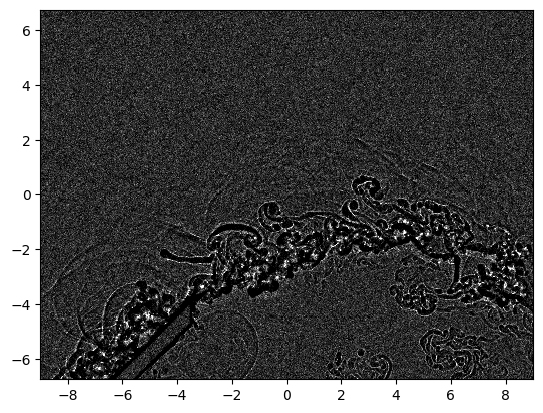

In [50]:
sh = rtm.LIONZ_approx(r0=rf) # must center grid
sh.solve(d1=d1,d2=d2)
sh.histogram(bin_scale = 7)

# plot
fig, axs = plt.subplots()
cm='gray'
vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H,95)
clim=(0,vmax*2.5) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

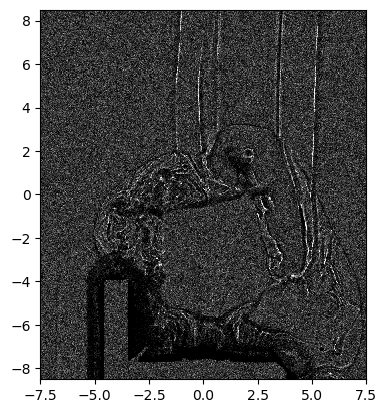

In [9]:
from matplotlib.colors import LogNorm

Lens_FL = 400
Lens_Rad = .5*75/2 # radius of lens

total_dist = 450+3600 # distance from target to first image plane
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1

sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = 10, L=Lens_FL, R=Lens_Rad) # must center grid
sh.solve(d1=d1,d2=d2)

sh.histogram(bin_scale = 7)
# plot
fig, axs = plt.subplots()
cm='gray'
#clim=[0,15]

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H,95)
clim=(0,vmax*2.5) # trial and error
sh.plot(axs, cmap=cm, clim=clim)


In [ ]:
#time=ds.current_time.to_value('ns')
#
#vmin=np.percentile(lsc.H, 5)
#vmax=np.percentile(lsc.H,95)
##clim=(0,vmax*3) # trial and error
#
#fig, ax = plt.subplots()
##ax.imshow(lsc.H, interpolation='nearest', clim=clim, origin='lower', cmap='grey',
##                extent=[sh.xedges[-1], lsc.xedges[0], lsc.yedges[-1], lsc.yedges[0]])
#
#ax.imshow(lsc.H, interpolation='nearest', origin='lower', cmap='grey',
#                extent=[sh.xedges[-1], lsc.xedges[0], lsc.yedges[-1], lsc.yedges[0]])
#
#ax.invert_xaxis()
#ax.invert_yaxis()
#ax.set_xlabel('x (mm)')
#ax.set_ylabel('y (mm)')
#ax.set_title(f'FLASH Shadowgraph, t={round(time, 2)}ns')
#print(os.getcwd())
#plt.savefig(f'./particle_tracking/shadowgraphs/sh_{file_num}_{photons}.png', bbox_inches='tight')